# Product Review Sentiment Analyzer

## Sentiment Classification of Amazon Product Reviews

This project develops a machine learning-based sentiment analyzer for classifying product reviews as **Positive** or **Negative**.

The project uses Amazon product reviews and applies basic text preprocessing before training the machine learning models. The preprocessing includes converting text to lowercase and removing punctuation.

Three machine learning models are trained and compared:

- Logistic Regression
- Multinomial Naive Bayes
- Linear Support Vector Machine (SVM)

The best-performing model is selected based on Accuracy, Precision, Recall, and F1 Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

# Dataset

The dataset used in this project is an Amazon product review dataset containing customer reviews and their corresponding ratings.

The original dataset contains:

- **568,454 reviews**
- **10 attributes**

For this project, only the following attributes are required:

- `Score` — numerical rating given by the customer.
- `Text` — written product review.

The remaining attributes are not required for sentiment classification and were removed.

In [2]:
df = pd.read_csv("Reviews.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (568454, 4)


In [3]:
df.head()

,Score,Text,Unnamed: 2,Unnamed: 3
0,5,I have bought several of the Vitality canned d...,NaN,NaN
1,1,Product arrived labeled as Jumbo Salted Peanut...,NaN,NaN
2,4,This is a confection that has been around a fe...,NaN,NaN
3,2,If you are looking for the secret ingredient i...,NaN,NaN
4,5,Great taffy at a great price. There was a wid...,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Score       568454 non-null  int64  
 1   Text        568454 non-null  object 
 2   Unnamed: 2  0 non-null       float64
 3   Unnamed: 3  0 non-null       float64
dtypes: float64(2), int64(1), object(1)
memory usage: 17.3+ MB


In [5]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Score   568454 non-null  int64 
 1   Text    568454 non-null  object
dtypes: int64(1), object(1)
memory usage: 8.7+ MB
None


In [6]:
print(df.isnull().sum())

Score    0
Text     0
dtype: int64


In [7]:
print(df['Score'].value_counts().sort_index())

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


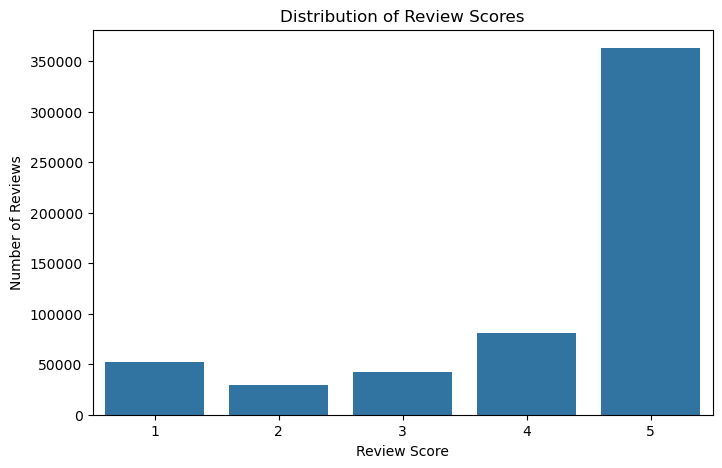

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Score', data=df)

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

# Sentiment Labeling

The original dataset contains review scores ranging from 1 to 5.

Since this project performs binary sentiment classification, the ratings were converted into two sentiment categories.

| Score | Sentiment |
|-------|-----------|
| 1 | Negative |
| 2 | Negative |
| 3 | Removed |
| 4 | Positive |
| 5 | Positive |

Three-star reviews were removed because they may represent neutral or mixed opinions and could make binary classification less clear.

After removing the neutral reviews, the dataset contained:

- Positive: 443,777 reviews
- Negative: 82,037 reviews

In [9]:
# Remove neutral reviews (Score = 3)
df = df[df['Score'] != 3].copy()

# Create binary sentiment labels
df['Sentiment'] = df['Score'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# Check the new class distribution
print(df['Sentiment'].value_counts())

Sentiment
Positive    443777
Negative     82037
Name: count, dtype: int64


## Dataset Balancing

The original dataset contains significantly more positive reviews than negative reviews.

To prevent the machine learning models from becoming biased toward the majority class, a balanced subset was created.

The final dataset contains:

- **50,000 Positive reviews**
- **50,000 Negative reviews**
- **100,000 total reviews**

The reviews were randomly selected using a fixed random state to ensure reproducibility.

The final dataset was also shuffled before model training.

In [10]:
# Separate positive and negative reviews
positive_reviews = df[df['Sentiment'] == 'Positive']
negative_reviews = df[df['Sentiment'] == 'Negative']

# Randomly select 50,000 reviews from each class
positive_sample = positive_reviews.sample(n=50000, random_state=42)
negative_sample = negative_reviews.sample(n=50000, random_state=42)

# Combine both samples
df = pd.concat([positive_sample, negative_sample])

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final dataset shape:", df.shape)
print("\nSentiment distribution:")
print(df['Sentiment'].value_counts())

Final dataset shape: (100000, 3)

Sentiment distribution:
Sentiment
Negative    50000
Positive    50000
Name: count, dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Score      100000 non-null  int64 
 1   Text       100000 non-null  object
 2   Sentiment  100000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.3+ MB


In [13]:
df.head()

,Score,Text,Sentiment
0,1,I was expecting a lot more from this coffee. I...,Negative
1,1,"POD is a generic word, and nothing in the desc...",Negative
2,5,"I recently purchased the Kerig coffee maker, a...",Positive
3,1,I'm just going to say it: These CHIPS Taste li...,Negative
4,2,This bread is very dry and crumbly compared to...,Negative


## Text Preprocessing

Basic text preprocessing was performed before training the machine learning models.

The preprocessing required for this project consists of:

1. Converting all text to lowercase.
2. Removing punctuation.

For example:

**Original:**

"This Product is AMAZING!!!"

**After lowercase conversion:**

"this product is amazing!!!"

**After punctuation removal:**

"this product is amazing"

The cleaned reviews were stored in a separate `Cleaned_Text` column while preserving the original review text.

In [14]:
# Display some original reviews
for i in range(5):
    print(f"Review {i+1}:")
    print(df['Text'].iloc[i])
    print("-" * 80)

Review 1:
I was expecting a lot more from this coffee. It was extremely bland and had very little coconut flavor. We couldn't even force ourselves to finish the cup. The only we have now is what to do with the remaining 22 K-cups we have left...
--------------------------------------------------------------------------------
Review 2:
POD is a generic word, and nothing in the description said that it was for Senseo machines. I'm glad it works for Senseo because it sure doesn't work in my espresso (Starbucks) machine.
--------------------------------------------------------------------------------
Review 3:
I recently purchased the Kerig coffee maker, and have been buying different coffee's to find the ones that I want to stay with and re order. I love a strong coffee, but not bitter .. this coffee is very nice, I make it by the mug, first I brew 6oz and then just add another 8oz. all with the same K-cup. and it is still nice and favorful.also has a nice mild lingering smoky after taste

In [15]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    return text

In [16]:
df['Cleaned_Text'] = df['Text'].apply(clean_text)

In [17]:
df[['Text', 'Cleaned_Text']].head()

,Text,Cleaned_Text
0,I was expecting a lot more from this coffee. I...,i was expecting a lot more from this coffee it...
1,"POD is a generic word, and nothing in the desc...",pod is a generic word and nothing in the descr...
2,"I recently purchased the Kerig coffee maker, a...",i recently purchased the kerig coffee maker an...
3,I'm just going to say it: These CHIPS Taste li...,im just going to say it these chips taste like...
4,This bread is very dry and crumbly compared to...,this bread is very dry and crumbly compared to...


In [18]:
empty_reviews = df['Cleaned_Text'].str.strip().eq('').sum()

print("Empty reviews after cleaning:", empty_reviews)

Empty reviews after cleaning: 0


In [19]:
# Features and target
X = df['Cleaned_Text']
y = df['Sentiment']

print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 100000
Number of labels: 100000


## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

- **80% — Training data:** 80,000 reviews
- **20% — Testing data:** 20,000 reviews

Stratified splitting was used to maintain the balanced distribution of Positive and Negative reviews in both sets.

A random state of 42 was used to ensure reproducibility.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 80000
Testing reviews: 20000


## TF-IDF Feature Extraction

Machine learning models cannot directly process raw text. Therefore, the cleaned reviews were converted into numerical features using **Term Frequency-Inverse Document Frequency (TF-IDF)**.

TF-IDF assigns importance to words based on their frequency within a review and their frequency across the complete collection of reviews.

The vectorizer was configured with:

- Maximum features: 10,000
- N-gram range: 1–2

This allows the model to learn both individual words and two-word combinations.

For example:

- `excellent`
- `product`
- `excellent product`
- `poor quality`

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [23]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [24]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80000, 10000)
Testing TF-IDF shape: (20000, 10000)


# 1. Logistic Regression

Logistic Regression was used as the first baseline classification model.

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [28]:
# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
['Positive' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Negative' 'Positive']


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9208
Precision: 0.9251
Recall   : 0.9158
F1 Score : 0.9204


# 2. Multinomial Naive Bayes

Multinomial Naive Bayes is a commonly used algorithm for text classification and was included as a second model for comparison.

In [30]:
from sklearn.naive_bayes import MultinomialNB

In [31]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [32]:
nb_pred = nb_model.predict(X_test_tfidf)

In [33]:
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    pos_label='Positive'
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    pos_label='Positive'
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    pos_label='Positive'
)

print(f"Naive Bayes Accuracy : {nb_accuracy:.4f}")
print(f"Naive Bayes Precision: {nb_precision:.4f}")
print(f"Naive Bayes Recall   : {nb_recall:.4f}")
print(f"Naive Bayes F1 Score : {nb_f1:.4f}")

Naive Bayes Accuracy : 0.8964
Naive Bayes Precision: 0.8988
Naive Bayes Recall   : 0.8934
Naive Bayes F1 Score : 0.8961


# 3. Linear Support Vector Machine

Linear SVM was used as the third model. Linear SVM is particularly suitable for high-dimensional text classification problems such as TF-IDF-based sentiment analysis.

In [34]:
from sklearn.svm import LinearSVC

In [35]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [36]:
svm_pred = svm_model.predict(X_test_tfidf)

In [37]:
svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision = precision_score(
    y_test,
    svm_pred,
    pos_label='Positive'
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    pos_label='Positive'
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    pos_label='Positive'
)

print(f"Linear SVM Accuracy : {svm_accuracy:.4f}")
print(f"Linear SVM Precision: {svm_precision:.4f}")
print(f"Linear SVM Recall   : {svm_recall:.4f}")
print(f"Linear SVM F1 Score : {svm_f1:.4f}")

Linear SVM Accuracy : 0.9227
Linear SVM Precision: 0.9279
Linear SVM Recall   : 0.9167
Linear SVM F1 Score : 0.9223


## Model Performance and Comparison

The three models produced the following results:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 92.08% | 92.51% | 91.58% | 92.04% |
| Naive Bayes | 89.64% | 89.88% | 89.34% | 89.61% |
| Linear SVM | **92.28%** | **92.79%** | **91.67%** | **92.23%** |

Linear SVM achieved the best performance across all four evaluation metrics.

Therefore, **Linear SVM was selected as the final sentiment classification model.**

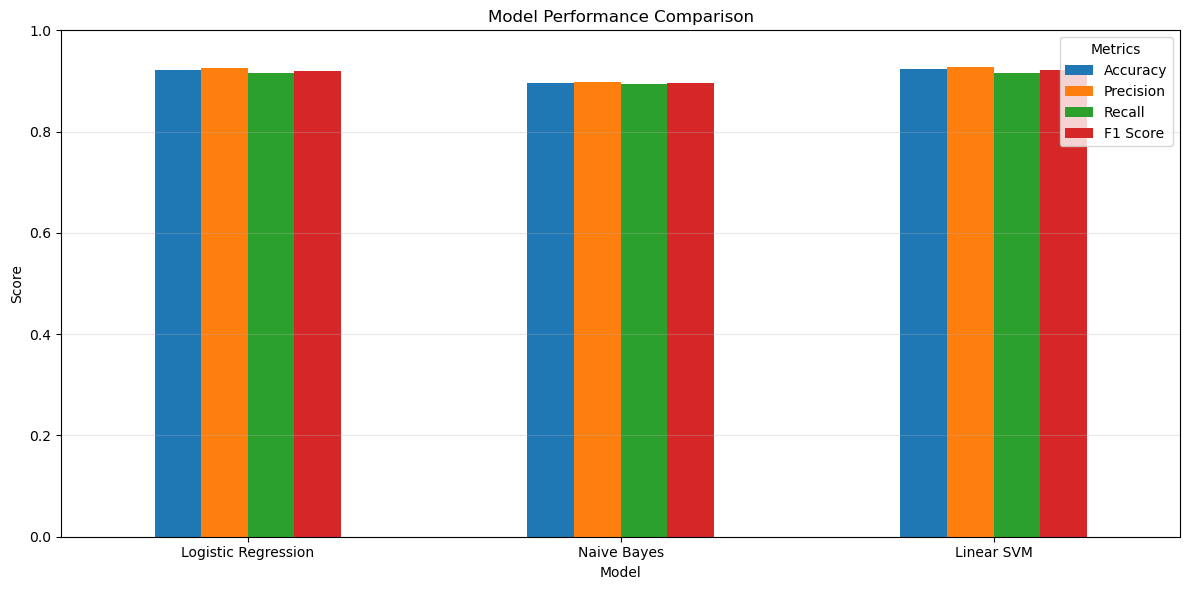

In [41]:
# Store model results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [accuracy, nb_accuracy, svm_accuracy],
    'Precision': [precision, nb_precision, svm_precision],
    'Recall': [recall, nb_recall, svm_recall],
    'F1 Score': [f1, nb_f1, svm_f1]
})

# Plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

ax = results.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Final Sentiment Analyzer

After comparing the three models, Linear SVM was selected as the final model.

The final prediction pipeline is:

User Review  
↓  
Lowercase Conversion  
↓  
Punctuation Removal  
↓  
TF-IDF Transformation  
↓  
Linear SVM  
↓  
Positive / Negative Prediction

The analyzer can accept a new product review and return its predicted sentiment.

In [58]:
def predict_sentiment(review):
    # Check empty input
    if not review or not review.strip():
        return "Invalid input: Please enter a product review."

    # Clean the review
    cleaned_review = clean_text(review)

    # Check if meaningful text remains
    if len(cleaned_review.split()) < 2:
        return "Invalid input: Please enter a complete product review."

    # Convert to TF-IDF
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict sentiment
    prediction = svm_model.predict(review_tfidf)[0]

    return prediction

# Limitations

The analyzer only checks for empty input and reviews containing fewer than two words. It does not detect irrelevant or non-product-related text, so such inputs may still be classified as Positive or Negative.

In [59]:
reviews = [
    "This product is amazing! I absolutely love it.",
    "Terrible product. It stopped working after one day.",
    "The quality is excellent and I am very satisfied.",
    "Complete waste of money. Very disappointed."
]

for review in reviews:
    prediction = predict_sentiment(review)
    
    print("Review:", review)
    print("Sentiment:", prediction)
    print("-" * 80)

Review: This product is amazing! I absolutely love it.
Sentiment: Positive
--------------------------------------------------------------------------------
Review: Terrible product. It stopped working after one day.
Sentiment: Negative
--------------------------------------------------------------------------------
Review: The quality is excellent and I am very satisfied.
Sentiment: Positive
--------------------------------------------------------------------------------
Review: Complete waste of money. Very disappointed.
Sentiment: Negative
--------------------------------------------------------------------------------


# Working realtime model for testing of product review analyzer 

In [62]:
review = input("Enter a product review: ")

result = predict_sentiment(review)

print("Predicted Sentiment:", result)

Enter a product review:  This is the worst product I have ever purchased.


Predicted Sentiment: Negative


## The project successfully developed a Product Review Sentiment Analyzer using TF-IDF and machine learning. Among the three models, Linear SVM performed best with 92.28% accuracy and was selected as the final model.